In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

In [7]:
from imblearn.over_sampling import SMOTE

In [9]:
#load the data set 
df = pd.read_csv(r"D:\OIBSIP\Credit Card Fraud Detection\creditcard.csv")

In [10]:
#first 5 rows 
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [12]:
# lat 5 rows 
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [13]:
#data size 
df. shape

(284807, 31)

In [15]:
#check the column  names
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [16]:
#understand the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [21]:
#checkning  the missing values 
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [23]:
#check the duplicated 
df.duplicated().sum()

np.int64(1081)

In [26]:
#check teh fraud vs legitimate transactions 
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [27]:
df["Class"].value_counts(normalize=True)*100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [28]:
df["Amount"]. describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

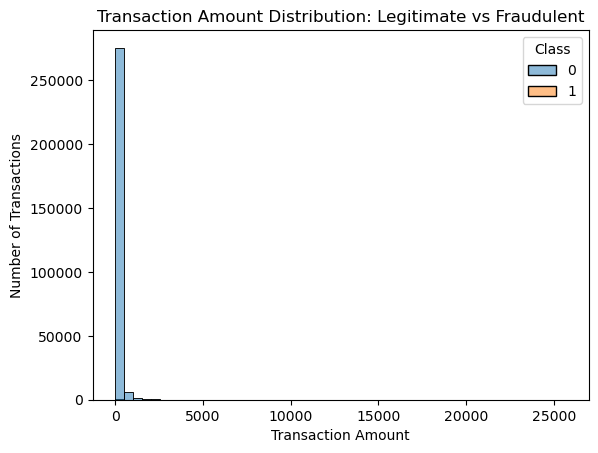

In [30]:
#Vplt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50
)

plt.title("Transaction Amount Distribution: Legitimate vs Fraudulent")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()


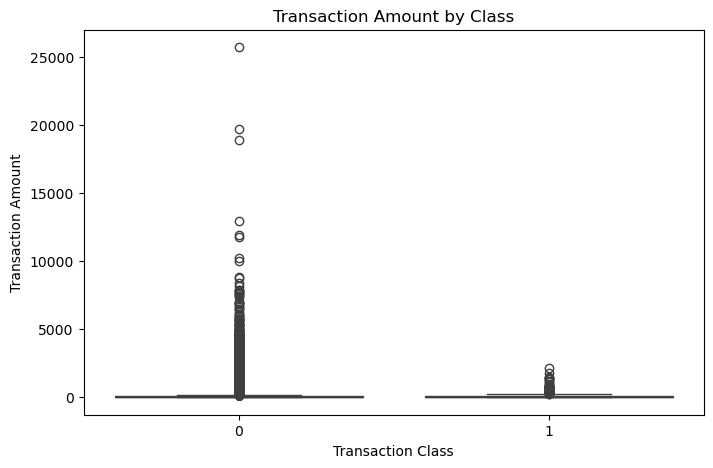

In [31]:
#Compare transaction amounts by class
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")

plt.show()

In [33]:
#Time-of-day analysis
df["Time"].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [37]:
#Create a hour feature 
df["Hour"] = ((df["Time"] / 3600) % 24).astype(int)

In [39]:
df[["Time", "Hour"]].head(10)

,Time,Hour
0,0.0,0
1,0.0,0
2,1.0,0
3,1.0,0
4,2.0,0
5,2.0,0
6,4.0,0
7,7.0,0
8,7.0,0
9,9.0,0


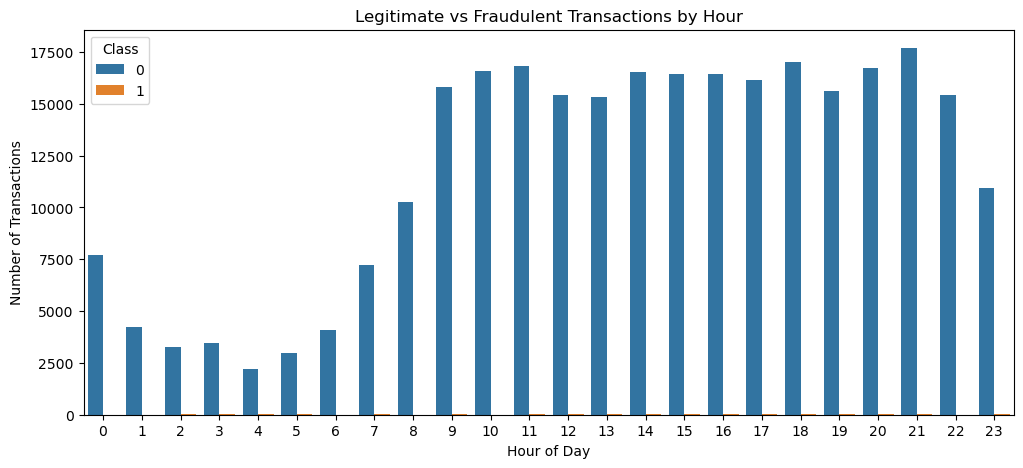

In [40]:
#Transactions by hour
plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x="Hour",
    hue="Class"
)

plt.title("Legitimate vs Fraudulent Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

In [41]:
#Fraud rate by hour
hourly_fraud_rate = df.groupby("Hour")["Class"].mean() * 100

hourly_fraud_rate

Hour
0     0.077973
1     0.236967
2     1.712740
3     0.486827
4     1.041195
5     0.367893
6     0.219459
7     0.317548
8     0.087583
9     0.101023
10    0.048199
11    0.314428
12    0.110246
13    0.110641
14    0.138805
15    0.157949
16    0.133714
17    0.179389
18    0.193673
19    0.121414
20    0.107424
21    0.090380
22    0.058286
23    0.191991
Name: Class, dtype: float64

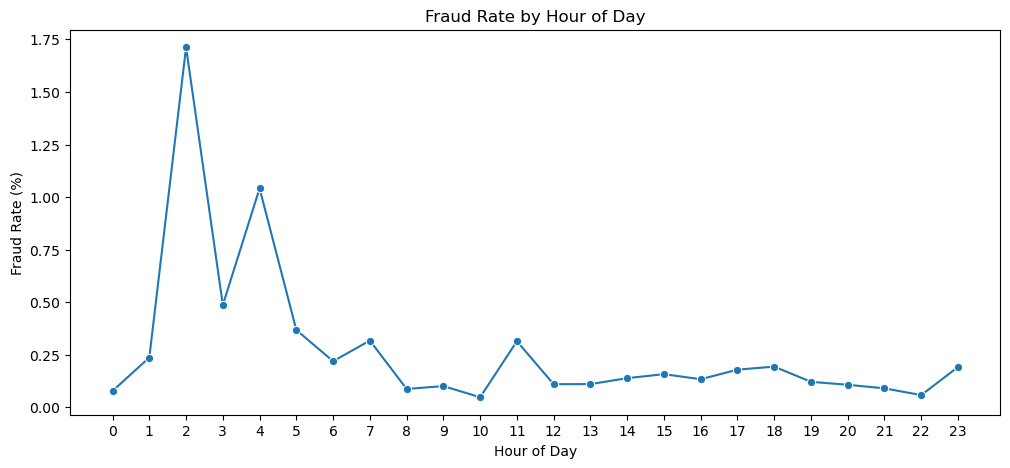

In [42]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    x=hourly_fraud_rate.index,
    y=hourly_fraud_rate.values,
    marker="o"
)

plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.show()

In [43]:
hourly_fraud_rate = df.groupby("Hour")["Class"].mean() * 100
hourly_fraud_rate

Hour
0     0.077973
1     0.236967
2     1.712740
3     0.486827
4     1.041195
5     0.367893
6     0.219459
7     0.317548
8     0.087583
9     0.101023
10    0.048199
11    0.314428
12    0.110246
13    0.110641
14    0.138805
15    0.157949
16    0.133714
17    0.179389
18    0.193673
19    0.121414
20    0.107424
21    0.090380
22    0.058286
23    0.191991
Name: Class, dtype: float64

In [46]:
### Observation

#The fraud rate varies across different hours of the day. The highest observed
#fraud rate occurs around 2 AM, followed by 4 AM and 3 AM. Most other hours
#have considerably lower fraud rates. This indicates that transaction time may
#contain useful information for fraud detection, although the hourly rates should
#be interpreted carefully because the total number of fraudulent transactions
#is very small.

In [47]:
#Compare Fraud vs Legitimate Features
feature_means = df.groupby("Class").mean(numeric_only=True).T

feature_means


Class,0,1
Time,94838.202258,80746.806911
V1,0.008258,-4.771948
V2,-0.006271,3.623778
V3,0.012171,-7.033281
V4,-0.007860,4.542029
V5,0.005453,-3.151225
V6,0.002419,-1.397737
V7,0.009637,-5.568731
V8,-0.000987,0.570636
V9,0.004467,-2.581123


In [48]:
#Visualize feature differences
feature_difference = (
    feature_means[1] - feature_means[0]
).abs().sort_values(ascending=False)

feature_difference.head(10)

Time      14091.395347
Amount       33.920299
V3            7.045452
V14           6.983787
V17           6.677371
V12           6.270225
V10           5.686707
V7            5.578368
V1            4.780206
V4            4.549889
dtype: float64

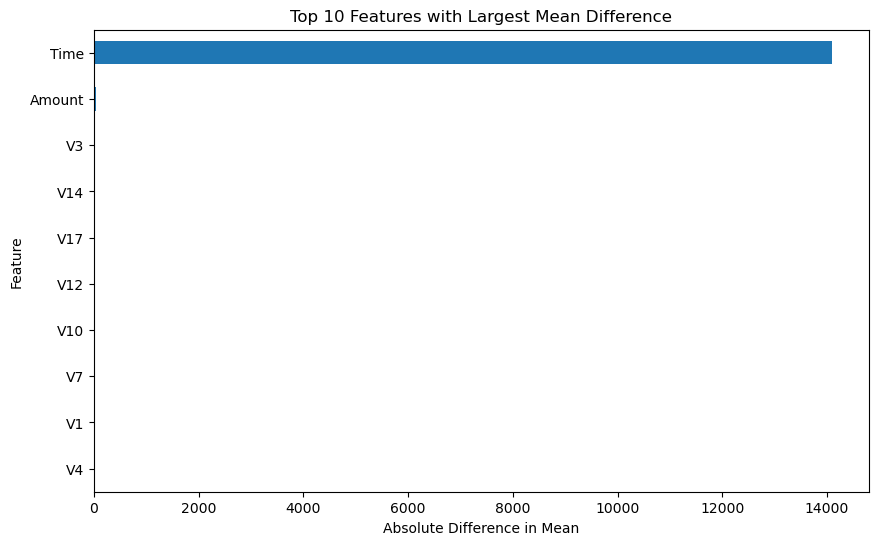

In [49]:
top_features = feature_difference.head(10).sort_values()

plt.figure(figsize=(10, 6))

top_features.plot(kind="barh")

plt.title("Top 10 Features with Largest Mean Difference")
plt.xlabel("Absolute Difference in Mean")
plt.ylabel("Feature")

plt.show()

In [50]:
v_features = [col for col in df.columns if col.startswith("V")]

feature_difference_v = (
    feature_means.loc[v_features, 1]
    - feature_means.loc[v_features, 0]
).abs().sort_values(ascending=False)

feature_difference_v.head(10)

V3     7.045452
V14    6.983787
V17    6.677371
V12    6.270225
V10    5.686707
V7     5.578368
V1     4.780206
V4     4.549889
V16    4.147110
V11    3.806749
dtype: float64

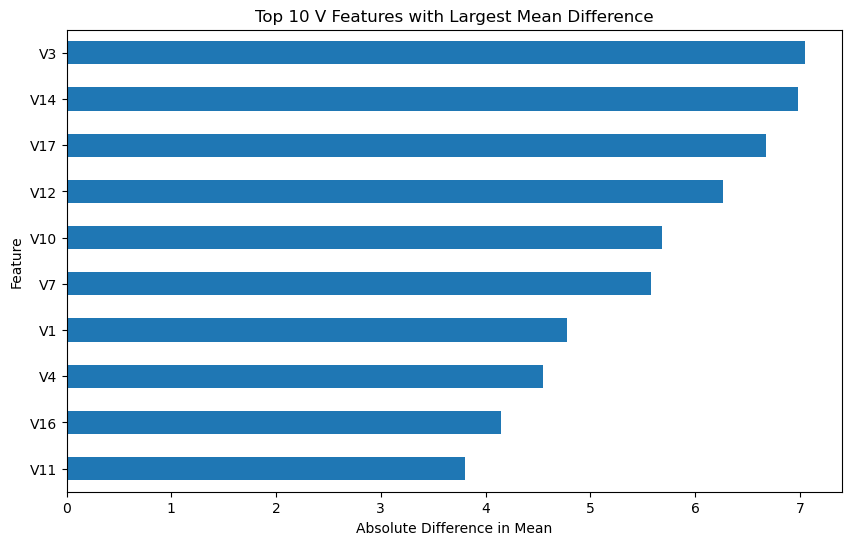

In [51]:
plt.figure(figsize=(10, 6))

feature_difference_v.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 V Features with Largest Mean Difference")
plt.xlabel("Absolute Difference in Mean")
plt.ylabel("Feature")

plt.show()

In [52]:
# accuracy explanation

#The dataset is highly imbalanced, with approximately 99.83% legitimate
#ransactions and only 0.17% fraudulent transactions. Because the majority
#class is much larger, a model could achieve very high accuracy simply by
#predicting most transactions as legitimate while failing to detect fraud.

#Therefore, accuracy alone is not an appropriate metric for this project.
#Precision, Recall, F1-Score and ROC-AUC will be used to evaluate the models.
#Recall is particularly important because missing an actual fraudulent
#transaction can have significant consequences.

In [59]:
X = df.drop(["Class", "Hour"], axis=1)
y = df["Class"]

In [60]:
X.shape

(284807, 30)

In [61]:
y.shape

(284807,)

In [62]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [63]:
print("Training set:")
print(y_train.value_counts())

print("\nTesting set:")
print(y_test.value_counts())

Training set:
Class
0    227451
1       394
Name: count, dtype: int64

Testing set:
Class
0    56864
1       98
Name: count, dtype: int64


In [64]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [65]:
from imblearn.over_sampling import SMOTE

In [66]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [67]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [68]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

In [69]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [70]:
lr_model.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [71]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [72]:
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

In [73]:
#Evaluate Logistic Regression
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_lr))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9708434302252134


In [74]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

cm_lr

array([[55397,  1467],
       [    8,    90]])

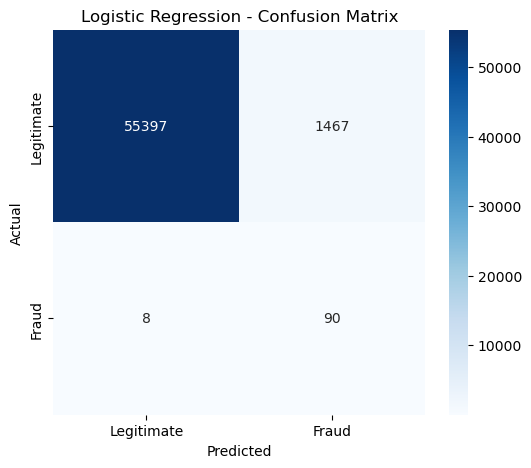

In [75]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [76]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

In [77]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [88]:
rf_model.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [89]:
#Predict the test data
y_pred_rf = rf_model.predict(X_test_scaled)

In [90]:
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

In [91]:
#Evaluate 
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9684484390970794


In [92]:
#Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_rf

array([[56852,    12],
       [   17,    81]])

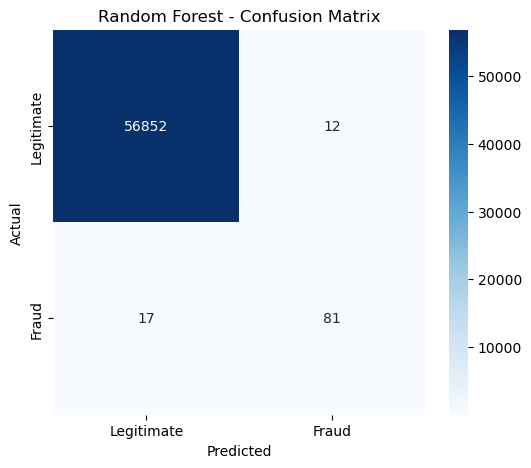

In [93]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [94]:
#Model Comparison Table
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [0.06, 0.87],
    "Recall": [0.92, 0.83],
    "F1-Score": [0.11, 0.85],
    "ROC-AUC": [0.9708, 0.9684]
})

model_comparison

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.06,0.92,0.11,0.9708
1,Random Forest,0.87,0.83,0.85,0.9684


In [95]:
#Feature Importance
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

V14    0.191127
V10    0.111454
V4     0.111395
V12    0.095690
V17    0.082761
V3     0.063935
V11    0.049290
V16    0.045124
V2     0.038541
V9     0.026552
dtype: float64

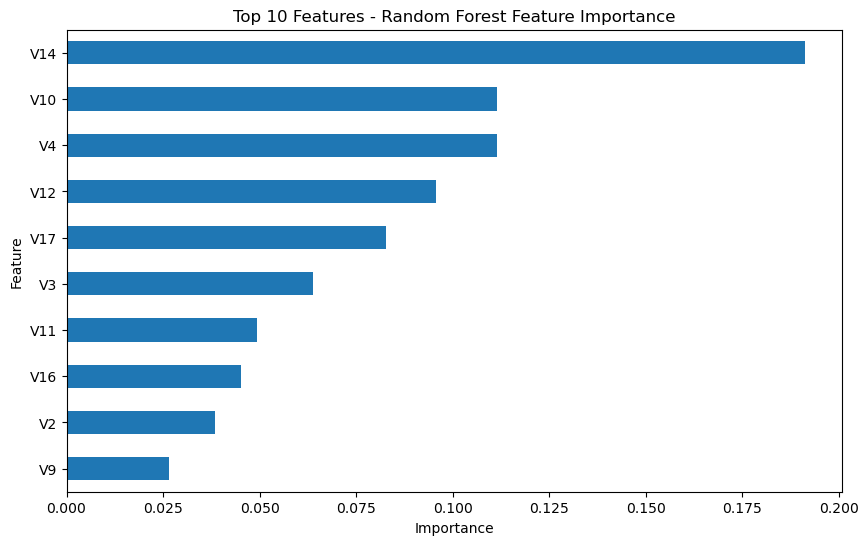

In [96]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Features - Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [98]:
#Precision–Recall Curve
from sklearn.metrics import precision_recall_curve

precision_lr, recall_lr, _ = precision_recall_curve(
    y_test, y_prob_lr
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test, y_prob_rf
)

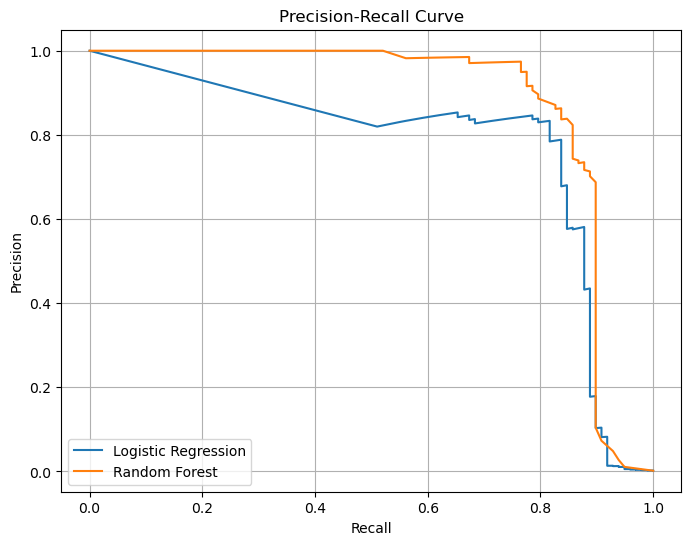

In [99]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_lr,
    precision_lr,
    label="Logistic Regression"
)

plt.plot(
    recall_rf,
    precision_rf,
    label="Random Forest"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()

plt.show()

In [100]:
#ROC Curve
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

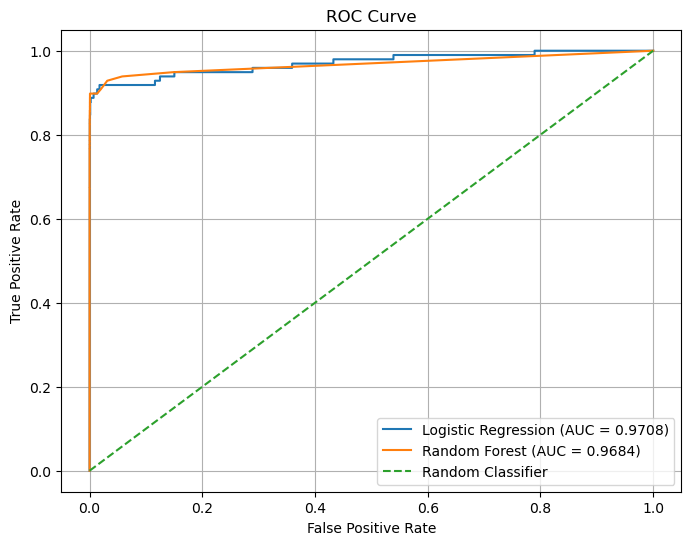

In [101]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label="Logistic Regression (AUC = 0.9708)"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest (AUC = 0.9684)"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

##  Precision vs Recall Trade-off

Fraud detection is an imbalanced classification problem, so accuracy alone is not a reliable evaluation metric.

Recall is important because it measures how many actual fraudulent transactions are correctly detected. A low recall means fraudulent transactions may be missed.

Precision is also important because it measures how many transactions predicted as fraud are actually fraudulent. Low precision results in more false alarms for legitimate customers.

In this project, Logistic Regression achieved a fraud recall of 0.92 but a precision of only 0.06. This means it detected most fraudulent transactions but generated many false positive alerts.

Random Forest achieved a fraud recall of 0.83 and a precision of 0.87. Although its recall was slightly lower, it produced far fewer false positive alerts.

Therefore, the appropriate balance between precision and recall depends on the business objective. In fraud detection, recall is particularly important because missing fraudulent transactions can result in financial losses. However, precision must also be considered because excessive false alerts can inconvenience legitimate customers.

## Scalability Considerations

#For a system processing 1 million transactions per hour, the fraud detection model would need to operate efficiently and close to real time.

The trained model could be deployed as a prediction service that receives transaction data and returns a fraud probability or fraud classification.

For large-scale processing, the system could use:
- Batch or streaming data pipelines
- Distributed processing
- Model monitoring and periodic retraining
- Real-time alerting for high-risk transactions

Random Forest can provide fast predictions after training, but for very high transaction volumes, the number of trees and model size should be optimized to maintain low prediction latency.

The system should also monitor changes in fraud patterns over time because fraud techniques can evolve. Periodic retraining would therefore be necessary.

## Business Insights

1. The dataset is highly imbalanced, with fraudulent transactions representing only a very small percentage of all transactions. Therefore, accuracy alone is not suitable for evaluating the fraud detection model.

2. SMOTE was applied to the training data to balance the minority fraud class and help the models learn fraudulent transaction patterns.

3. Logistic Regression achieved a fraud recall of 92%, meaning it detected most fraudulent transactions. However, its precision was only 6%, resulting in many false positive alerts.

4. Random Forest achieved a fraud precision of 87%, recall of 83%, and F1-score of 85%. It produced significantly fewer false positives than Logistic Regression.

5. V14 was the most important feature according to the Random Forest feature-importance analysis, followed by V10, V4, V12, and V17.

6. The Precision-Recall and ROC curves show that both models can distinguish fraudulent transactions from legitimate transactions, while their precision-recall trade-offs differ.

7. For a real-world fraud detection system, the choice of model and classification threshold should depend on the business cost of missed fraud versus false fraud alerts.